In [2]:
import pandas as pd
import seaborn as sns
import matplotlib
matplotlib.use("Agg") 
%matplotlib inline
import matplotlib.pyplot as plt
import argparse  
import sqlite3
from threading import Thread

cnx = sqlite3.connect('./data_copy.db')
try:
    cnx.execute('''
            CREATE INDEX IF NOT EXISTS idx_elasticity_lookup 
            ON data (experiment, provider, date_time, language, cpu, memory, timestamp)
    ''')
    cnx.commit()
    print("Index created/verified")
except Exception as e:
    print(f"Index creation note: {e}")

Index created/verified


/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_96558/2874838470.py:86: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_tail.groupby(["hour_bin", "band"]).size().unstack(fill_value=0)


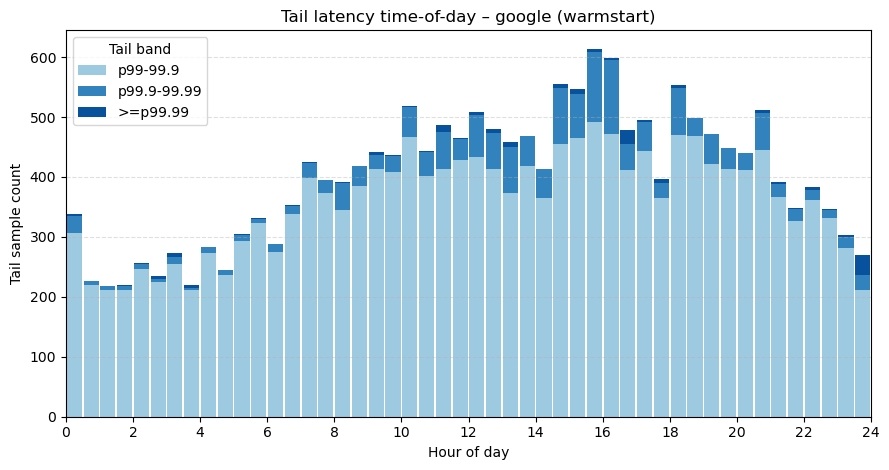

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_96558/2874838470.py:86: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_tail.groupby(["hour_bin", "band"]).size().unstack(fill_value=0)


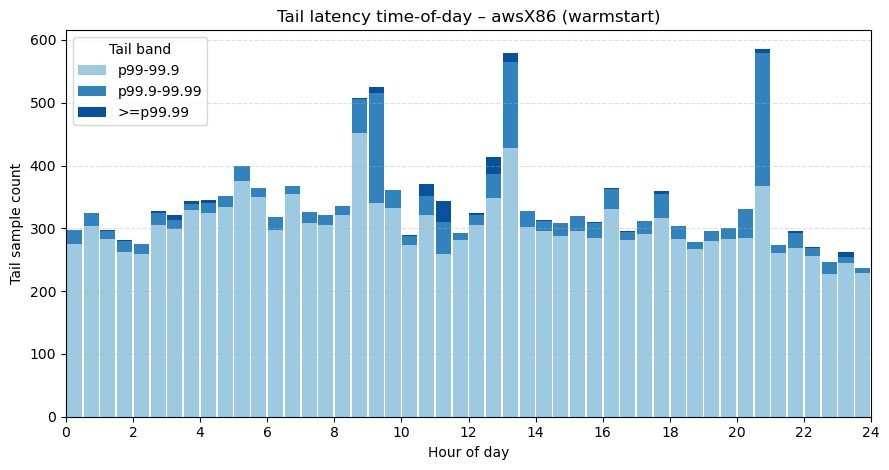

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_96558/2874838470.py:86: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_tail.groupby(["hour_bin", "band"]).size().unstack(fill_value=0)


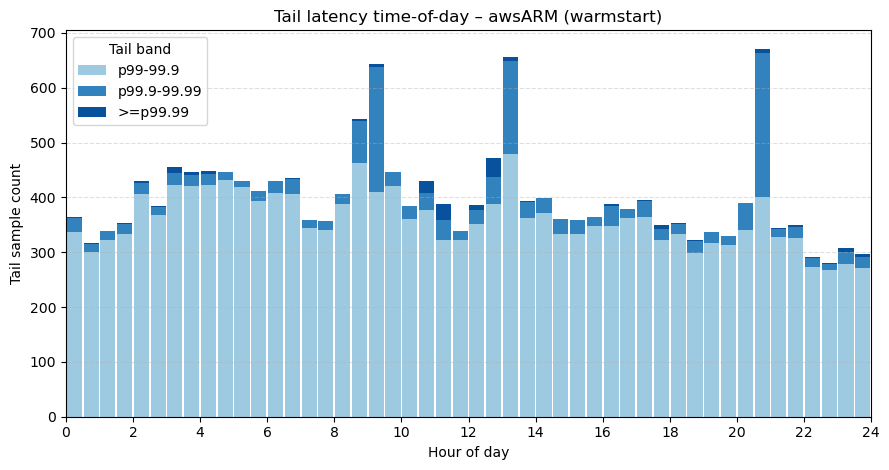

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_96558/2874838470.py:86: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_tail.groupby(["hour_bin", "band"]).size().unstack(fill_value=0)


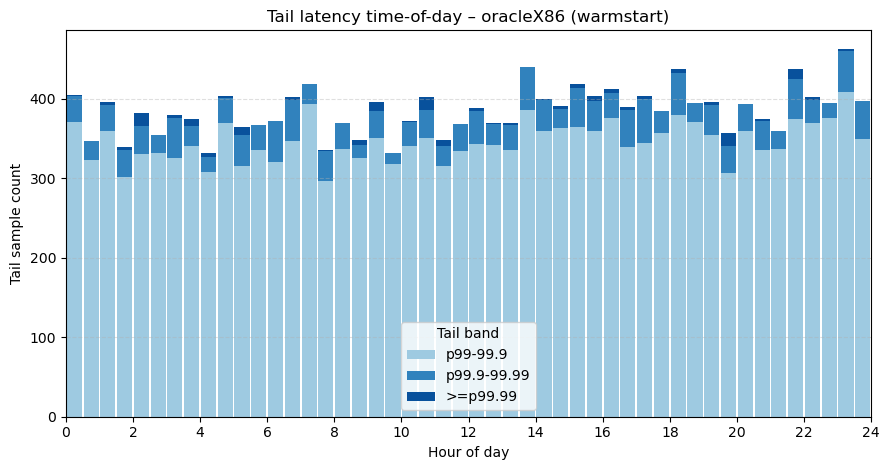

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_96558/2874838470.py:86: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_tail.groupby(["hour_bin", "band"]).size().unstack(fill_value=0)


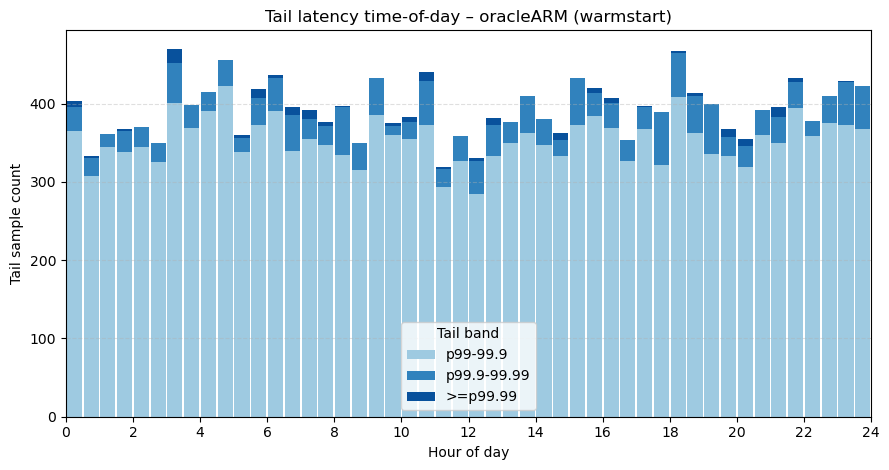

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_96558/2874838470.py:86: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_tail.groupby(["hour_bin", "band"]).size().unstack(fill_value=0)


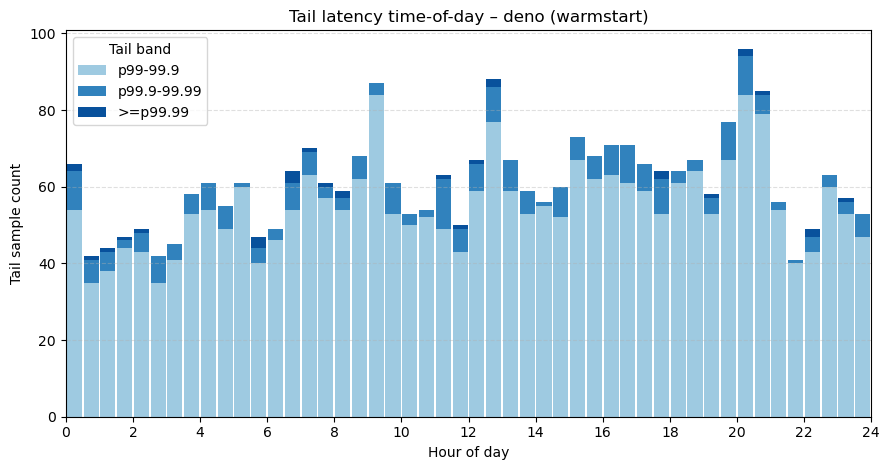

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_96558/2874838470.py:86: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_tail.groupby(["hour_bin", "band"]).size().unstack(fill_value=0)


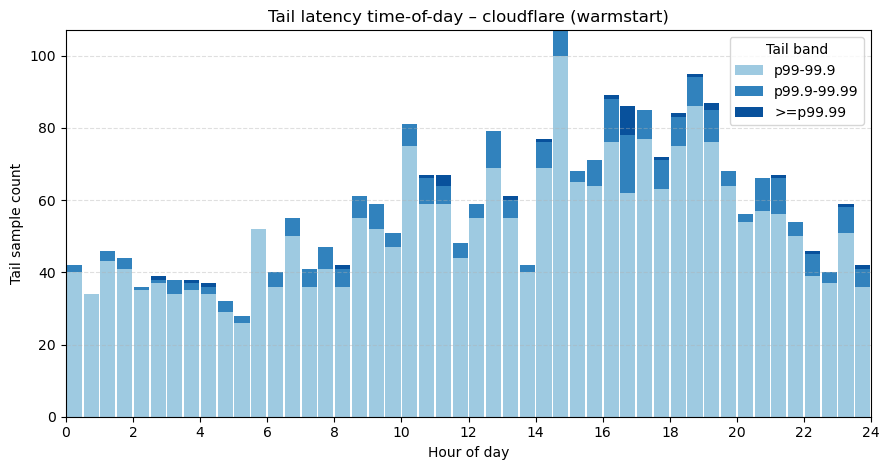

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_96558/2874838470.py:86: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_tail.groupby(["hour_bin", "band"]).size().unstack(fill_value=0)


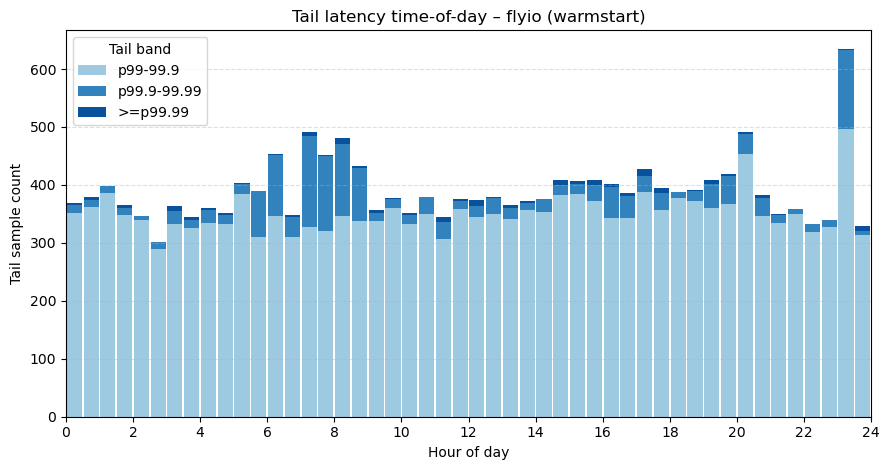

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_96558/2874838470.py:86: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_tail.groupby(["hour_bin", "band"]).size().unstack(fill_value=0)


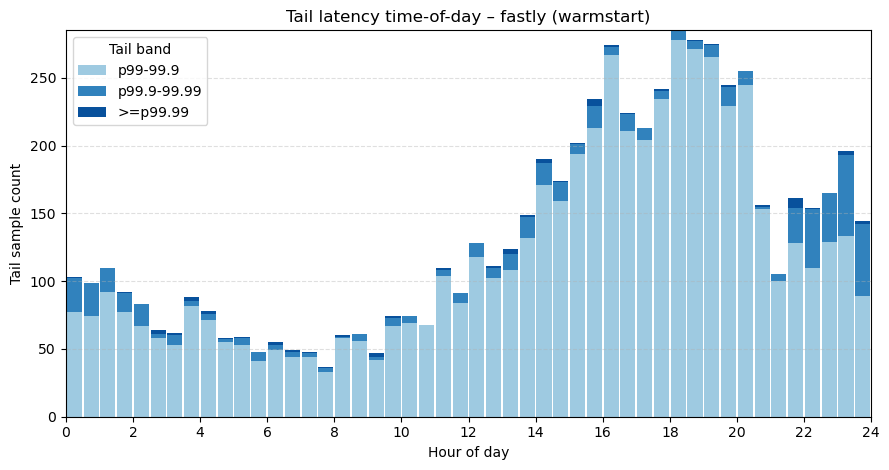

In [4]:
# Tail latency time-of-day distribution per provider (stacked bands)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

providers = ["google", "awsX86", "awsARM", "oracleX86", "oracleARM", "deno", "cloudflare", "flyio", "fastly"]
experiment = "warmstart"  # "warmstart" or "coldstart"
bins = np.linspace(0, 24, 49)  # 30-minute bins
bin_centers = 0.5 * (bins[:-1] + bins[1:])

band_colors = {
    "p99-99.9": "#9ecae1",
    "p99.9-99.99": "#3182bd",
    ">=p99.99": "#08519c",
}

for provider in providers:
    if experiment == "warmstart" and provider != "fastly":
        query = """
            SELECT date_time, http_req_waiting
            FROM data
            WHERE provider = ?
              AND experiment = 'warmstart'
              AND cold_starts = 0
        """
        params = [provider]
    elif experiment == "warmstart" and provider == "fastly":
        query = """
            SELECT date_time, http_req_waiting
            FROM data
            WHERE provider = ?
              AND experiment = 'warmstart'
        """
        params = [provider]
    else:
        query = """
            SELECT date_time, http_req_waiting
            FROM data
            WHERE provider = ?
              AND experiment = 'coldstart'
              AND cold_starts = 1
        """
        params = [provider]

    df = pd.read_sql_query(query, cnx, params=params)
    if df.empty:
        print(f"No data for provider {provider} ({experiment}).")
        continue

    df["http_req_waiting"] = pd.to_numeric(df["http_req_waiting"], errors="coerce")
    df = df.dropna(subset=["http_req_waiting", "date_time"])

    if df.empty:
        print(f"No usable data for provider {provider} ({experiment}).")
        continue

    p99 = df["http_req_waiting"].quantile(0.99)
    p999 = df["http_req_waiting"].quantile(0.999)
    p9999 = df["http_req_waiting"].quantile(0.9999)

    dt = pd.to_datetime(df["date_time"], format="%Y-%m-%dT%H-%M-%S", errors="coerce")
    df = df[dt.notna()].copy()
    if df.empty:
        print(f"No parsable timestamps for provider {provider} ({experiment}).")
        continue

    dt = dt[dt.notna()]
    hours = dt.dt.hour + (dt.dt.minute / 60.0) + (dt.dt.second / 3600.0)
    df["hour_bin"] = pd.cut(hours, bins=bins, labels=bin_centers, include_lowest=True)

    df_tail = df[df["http_req_waiting"] >= p99].copy()
    if df_tail.empty:
        print(f"No tail samples for provider {provider} ({experiment}).")
        continue

    def assign_band(x: float) -> str:
        if x >= p9999:
            return ">=p99.99"
        if x >= p999:
            return "p99.9-99.99"
        return "p99-99.9"

    df_tail["band"] = df_tail["http_req_waiting"].apply(assign_band)
    counts = (
        df_tail.groupby(["hour_bin", "band"]).size().unstack(fill_value=0)
    )
    for band in ["p99-99.9", "p99.9-99.99", ">=p99.99"]:
        if band not in counts.columns:
            counts[band] = 0
    counts = counts[["p99-99.9", "p99.9-99.99", ">=p99.99"]]
    counts = counts.reindex(bin_centers, fill_value=0)

    plt.figure(figsize=(9.0, 4.8))
    bottom = np.zeros(len(bin_centers))
    for band in counts.columns:
        values = counts[band].to_numpy()
        plt.bar(bin_centers, values, width=(bins[1] - bins[0]) * 0.9, bottom=bottom, color=band_colors[band], label=band)
        bottom += values

    plt.title(f"Tail latency time-of-day – {provider} ({experiment})")
    plt.xlabel("Hour of day")
    plt.ylabel("Tail sample count")
    plt.xlim(0, 24)
    plt.xticks(range(0, 25, 2))
    plt.grid(True, linestyle="--", alpha=0.4, axis="y")
    plt.legend(title="Tail band")
    plt.tight_layout()
    plt.show()

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_96558/1212818765.py:84: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df_tail.groupby("hour_bin").size()
/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_96558/1212818765.py:84: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df_tail.groupby("hour_bin").size()
/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_96558/1212818765.py:84: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to ad

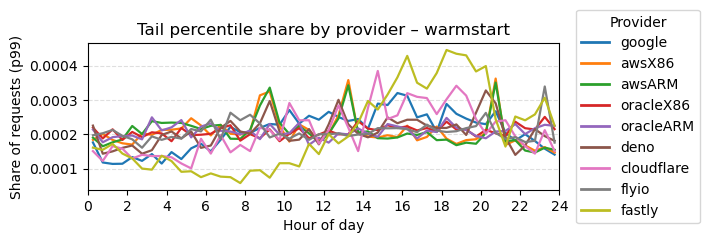

In [11]:
# Tail latency percentile counts by provider (cumulative lines)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.lines import Line2D

providers = ["google", "awsX86", "awsARM", "oracleX86", "oracleARM", "deno", "cloudflare", "flyio", "fastly"]
experiment = "warmstart"  # "warmstart" or "coldstart"
bins = np.linspace(0, 24, 49)  # 30-minute bins
bin_centers = 0.5 * (bins[:-1] + bins[1:])

percentiles = [(0.99, "p99")]
line_styles = {"p99": "-"}

palette = sns.color_palette("tab10", n_colors=len(providers))
provider_colors = dict(zip(providers, palette))

fig, ax = plt.subplots(figsize=(7.2, 2.4))

providers_with_data = []
provider_colors_with_data = []

for provider in providers:
    if experiment == "warmstart" and provider != "fastly":
        query = """
            SELECT date_time, http_req_waiting
            FROM data
            WHERE provider = ?
              AND experiment = 'warmstart'
              AND cold_starts = 0
        """
        params = [provider]
    elif experiment == "warmstart" and provider == "fastly":
        query = """
            SELECT date_time, http_req_waiting
            FROM data
            WHERE provider = ?
              AND experiment = 'warmstart'
        """
        params = [provider]
    else:
        query = """
            SELECT date_time, http_req_waiting
            FROM data
            WHERE provider = ?
              AND experiment = 'coldstart'
              AND cold_starts = 1
        """
        params = [provider]

    df = pd.read_sql_query(query, cnx, params=params)
    if df.empty:
        print(f"No data for provider {provider} ({experiment}).")
        continue

    df["http_req_waiting"] = pd.to_numeric(df["http_req_waiting"], errors="coerce")
    df = df.dropna(subset=["http_req_waiting", "date_time"])

    if df.empty:
        print(f"No usable data for provider {provider} ({experiment}).")
        continue

    dt = pd.to_datetime(df["date_time"], format="%Y-%m-%dT%H-%M-%S", errors="coerce")
    df = df[dt.notna()].copy()
    if df.empty:
        print(f"No parsable timestamps for provider {provider} ({experiment}).")
        continue

    total_requests = len(df)
    if total_requests == 0:
        print(f"No requests for provider {provider} ({experiment}).")
        continue

    dt = dt[dt.notna()]
    hours = dt.dt.hour + (dt.dt.minute / 60.0) + (dt.dt.second / 3600.0)
    df["hour_bin"] = pd.cut(hours, bins=bins, labels=bin_centers, include_lowest=True)

    thresholds = {label: df["http_req_waiting"].quantile(q) for q, label in percentiles}
    for label in ["p99"]:
        thr = thresholds[label]
        df_tail = df[df["http_req_waiting"] >= thr]
        counts = df_tail.groupby("hour_bin").size()
        counts = counts.reindex(bin_centers, fill_value=0)
        shares = counts / total_requests
        ax.plot(
            bin_centers,
            shares.to_numpy(),
            color=provider_colors[provider],
            linestyle=line_styles[label],
            linewidth=1.6,
            label=f"{provider} {label}",
        )
        if provider not in providers_with_data:
            providers_with_data.append(provider)
            provider_colors_with_data.append(provider_colors[provider])

ax.set_title(f"Tail percentile share by provider – {experiment}")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Share of requests (p99)")
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 2))
ax.grid(True, linestyle="--", alpha=0.4, axis="y")
if providers_with_data:
    legend_handles = [Line2D([0], [0], color=color, lw=2) for color in provider_colors_with_data]
    ax.legend(
        legend_handles,
        providers_with_data,
        title="Provider",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=True,
    )
fig.subplots_adjust(right=0.78)
fig.tight_layout()

export_dir = Path("figures") / "10_tail_latency_occurrence"
export_dir.mkdir(parents=True, exist_ok=True)

export_path = export_dir / "p99_share_by_provider_time_of_day.pdf"
fig.savefig(export_path, bbox_inches="tight")
plt.show()
plt.close(fig)

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_96558/670107012.py:48: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_all["hour_bin"] = dt_all[dt_all.notna()].dt.floor("H")
/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_96558/670107012.py:73: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_warm["hour_bin"] = dt_warm[dt_warm.notna()].dt.floor("H")


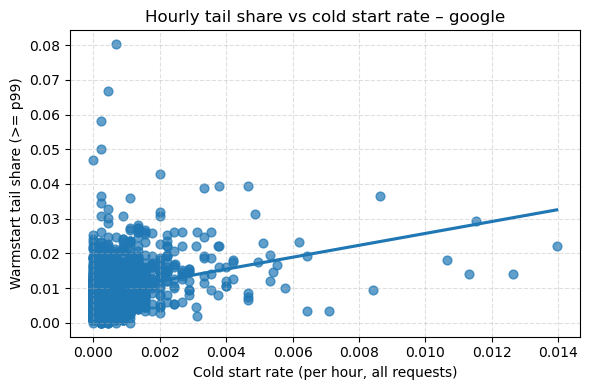

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_96558/670107012.py:48: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_all["hour_bin"] = dt_all[dt_all.notna()].dt.floor("H")
/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_96558/670107012.py:73: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_warm["hour_bin"] = dt_warm[dt_warm.notna()].dt.floor("H")


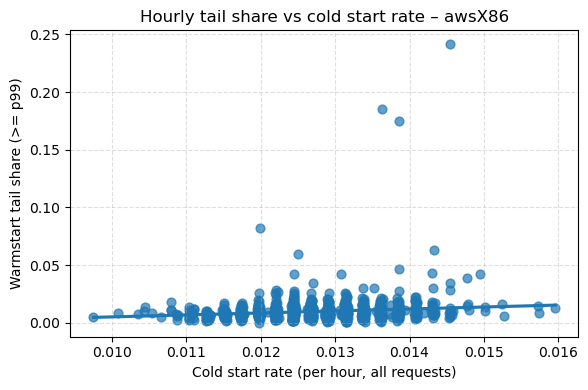

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_96558/670107012.py:48: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_all["hour_bin"] = dt_all[dt_all.notna()].dt.floor("H")
/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_96558/670107012.py:73: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_warm["hour_bin"] = dt_warm[dt_warm.notna()].dt.floor("H")


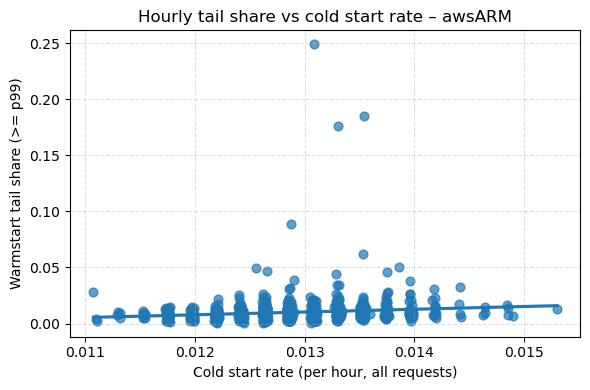

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_96558/670107012.py:48: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_all["hour_bin"] = dt_all[dt_all.notna()].dt.floor("H")
/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_96558/670107012.py:73: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_warm["hour_bin"] = dt_warm[dt_warm.notna()].dt.floor("H")


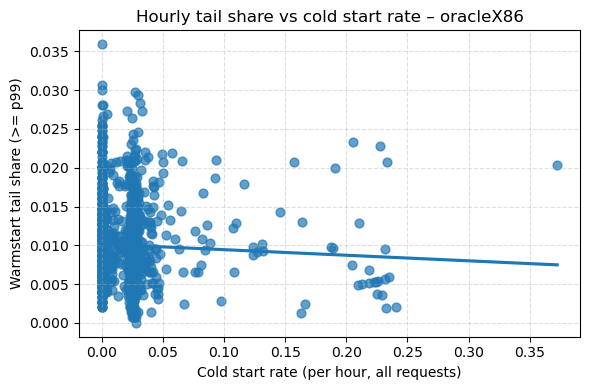

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_96558/670107012.py:48: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_all["hour_bin"] = dt_all[dt_all.notna()].dt.floor("H")
/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_96558/670107012.py:73: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_warm["hour_bin"] = dt_warm[dt_warm.notna()].dt.floor("H")


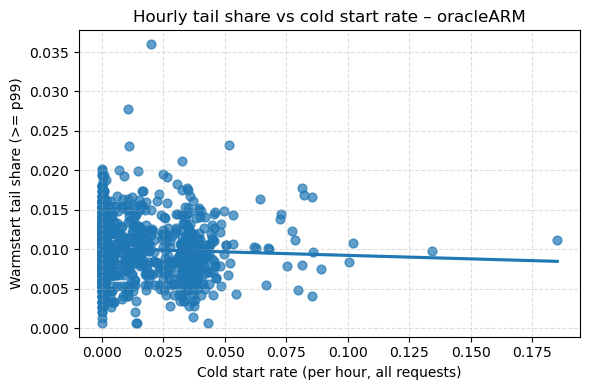

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_96558/670107012.py:48: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_all["hour_bin"] = dt_all[dt_all.notna()].dt.floor("H")
/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_96558/670107012.py:73: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_warm["hour_bin"] = dt_warm[dt_warm.notna()].dt.floor("H")


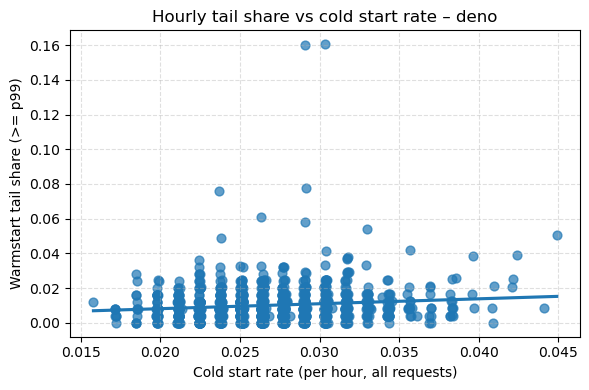

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_96558/670107012.py:48: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_all["hour_bin"] = dt_all[dt_all.notna()].dt.floor("H")
/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_96558/670107012.py:73: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_warm["hour_bin"] = dt_warm[dt_warm.notna()].dt.floor("H")


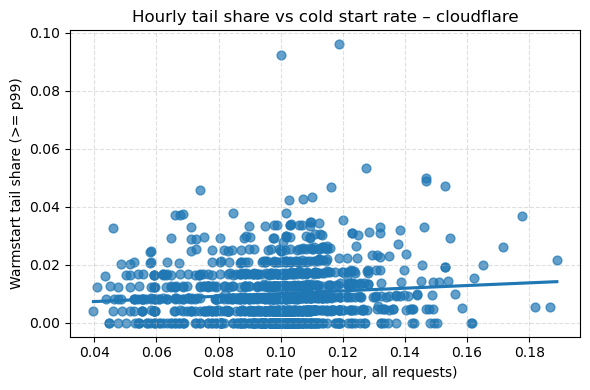

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_96558/670107012.py:48: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_all["hour_bin"] = dt_all[dt_all.notna()].dt.floor("H")
/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_96558/670107012.py:73: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_warm["hour_bin"] = dt_warm[dt_warm.notna()].dt.floor("H")


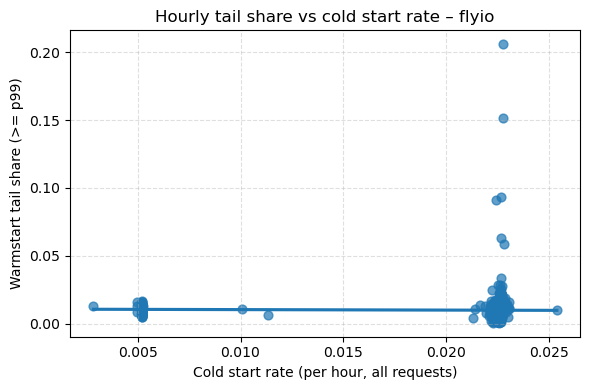

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_96558/670107012.py:48: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_all["hour_bin"] = dt_all[dt_all.notna()].dt.floor("H")


No warmstart data for provider fastly.


In [14]:
# Hourly tail share (warmstarts) vs cold start rate (all requests) per provider
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

providers = ["google", "awsX86", "awsARM", "oracleX86", "oracleARM", "deno", "cloudflare", "flyio", "fastly"]
tail_q = 0.99  # tail threshold from warmstart distribution

def load_provider_all(provider: str) -> pd.DataFrame:
    query = """
        SELECT date_time, http_req_waiting, cold_starts, experiment
        FROM data
        WHERE provider = ?
    """
    return pd.read_sql_query(query, cnx, params=[provider])

def load_provider_warm(provider: str) -> pd.DataFrame:
    query = """
        SELECT date_time, http_req_waiting
        FROM data
        WHERE provider = ?
          AND experiment = 'warmstart'
          AND cold_starts = 0
    """
    return pd.read_sql_query(query, cnx, params=[provider])

for provider in providers:
    df_all = load_provider_all(provider)
    if df_all.empty:
        print(f"No data for provider {provider}.")
        continue

    df_all["http_req_waiting"] = pd.to_numeric(df_all["http_req_waiting"], errors="coerce")
    df_all["cold_starts"] = pd.to_numeric(df_all["cold_starts"], errors="coerce")
    df_all = df_all.dropna(subset=["http_req_waiting", "cold_starts", "date_time"])

    if df_all.empty:
        print(f"No usable data for provider {provider}.")
        continue

    dt_all = pd.to_datetime(df_all["date_time"], format="%Y-%m-%dT%H-%M-%S", errors="coerce")
    df_all = df_all[dt_all.notna()].copy()
    if df_all.empty:
        print(f"No parsable timestamps for provider {provider}.")
        continue

    df_all["hour_bin"] = dt_all[dt_all.notna()].dt.floor("H")
    cold_by_hour = df_all.groupby("hour_bin").agg(
        total_all=("cold_starts", "size"),
        cold_rate=("cold_starts", "mean"),
    )
    cold_by_hour = cold_by_hour[cold_by_hour["total_all"] > 0]

    df_warm = load_provider_warm(provider)
    if df_warm.empty:
        print(f"No warmstart data for provider {provider}.")
        continue

    df_warm["http_req_waiting"] = pd.to_numeric(df_warm["http_req_waiting"], errors="coerce")
    df_warm = df_warm.dropna(subset=["http_req_waiting", "date_time"])

    if df_warm.empty:
        print(f"No usable warmstart data for provider {provider}.")
        continue

    dt_warm = pd.to_datetime(df_warm["date_time"], format="%Y-%m-%dT%H-%M-%S", errors="coerce")
    df_warm = df_warm[dt_warm.notna()].copy()
    if df_warm.empty:
        print(f"No parsable warmstart timestamps for provider {provider}.")
        continue

    df_warm["hour_bin"] = dt_warm[dt_warm.notna()].dt.floor("H")
    tail_cut = df_warm["http_req_waiting"].quantile(tail_q)
    warm_by_hour = df_warm.groupby("hour_bin").agg(
        total_warm=("http_req_waiting", "size"),
        tail_warm=("http_req_waiting", lambda s: (s >= tail_cut).sum()),
    )
    warm_by_hour = warm_by_hour[warm_by_hour["total_warm"] > 0]
    warm_by_hour["tail_share"] = warm_by_hour["tail_warm"] / warm_by_hour["total_warm"]

    joined = cold_by_hour.join(warm_by_hour[["tail_share"]], how="inner")
    if joined.empty:
        print(f"No overlapping hourly bins for provider {provider}.")
        continue

    x = joined["cold_rate"].to_numpy()
    y = joined["tail_share"].to_numpy()
    if len(x) < 2:
        print(f"Not enough points for regression for provider {provider}.")
        continue

    plt.figure(figsize=(6.0, 4.0))
    sns.regplot(x=x, y=y, ci=None, scatter_kws={"s": 40, "alpha": 0.7})
    plt.title(f"Hourly tail share vs cold start rate – {provider}")
    plt.xlabel("Cold start rate (per hour, all requests)")
    plt.ylabel(f"Warmstart tail share (>= p{int(tail_q * 100)})")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()